In [1]:
path_masked_gs = "/data/users/jaeyeonpark/DGE-outputs/edit_cache/A man_mask_30_view/gs_mask.pt"
# analyze the mask file


In [2]:
import torch

path_masked_gs = "/data/users/jaeyeonpark/DGE-outputs/edit_cache/A man_mask_30_view/gs_mask.pt"

obj = torch.load(path_masked_gs, map_location="cuda")
print("type:", type(obj))

if isinstance(obj, dict):
    print("dict keys:", list(obj.keys()))
    for k, v in obj.items():
        try:
            if hasattr(v, "shape"):
                print(f"  key={k}, type={type(v)}, shape={tuple(v.shape)}")
            else:
                print(f"  key={k}, type={type(v)}")
        except Exception as e:
            print(f"  key={k}, error inspecting value:", e)
elif isinstance(obj, (list, tuple)):
    print("len:", len(obj))
    for i, v in enumerate(obj[:10]):
        try:
            if hasattr(v, "shape"):
                print(f"  idx={i}, type={type(v)}, shape={tuple(v.shape)}")
            else:
                print(f"  idx={i}, type={type(v)}")
        except Exception as e:
            print(f"  idx={i}, error inspecting value:", e)
else:
    # generic object
    print("repr:", repr(obj))



/tmp/ipykernel_3669969/1979231420.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(path_masked_gs, map_location="cuda")


type: <class 'torch.Tensor'>
repr: tensor([False,  True, False,  ..., False, False, False], device='cuda:0')


In [4]:
path_ply = "/working/style-transfer/VcEdit/gs_data/trained_gs_models/face/point_cloud.ply"


import torch
import sys, os

# 프로젝트 루트 경로를 Python path에 추가
proj_root = "/working/style-transfer/DGE"
if proj_root not in sys.path:
    sys.path.append(proj_root)
from gaussiansplatting.scene.gaussian_model_origin import GaussianModel

# PLY 경로
path_ply = "/working/style-transfer/VcEdit/gs_data/trained_gs_models/face/point_cloud.ply"

# 대략적인 초기값 (분석용이라 값은 크게 중요하지 않음)
gm = GaussianModel(
    sh_degree=3,
    anchor_weight_init_g0=0.0,
    anchor_weight_init=0.0,
    anchor_weight_multiplier=1.0,
)

# PLY에서 Gaussian 로드
gm.load_ply(path_ply)

print("xyz shape:", gm.get_xyz.shape)
print("features shape:", gm.get_features.shape)
print("opacity shape:", gm.get_opacity.shape)



/opt/conda/lib/python3.11/site-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xyz shape: torch.Size([668082, 3])
features shape: torch.Size([668082, 16, 3])
opacity shape: torch.Size([668082, 1])


In [1]:
import torch
import sys, os

# 프로젝트 루트 추가
proj_root = "/working/style-transfer/DGE"
if proj_root not in sys.path:
    sys.path.append(proj_root)

from gaussiansplatting.scene.gaussian_model_origin import GaussianModel

# PLY 경로
path_ply = "/working/style-transfer/VcEdit/gs_data/trained_gs_models/face/point_cloud.ply"
path_ply = "/data/users/jaeyeonpark/3dgs-trained/3d-ovs/covered_desk/point_cloud/iteration_30000/point_cloud.ply"

# 마스크 pt 경로
path_masked_gs = "/data/users/jaeyeonpark/DGE-outputs/edit_cache/A man_mask_30_view/gs_mask.pt"
path_masked_gs = "/data/users/jaeyeonpark/DGE-outputs/edit_cache/bear with red t-shirt_mask_30_view/gs_mask.pt" 

# 1) Gaussian 로드
gm = GaussianModel(
    sh_degree=3,
    anchor_weight_init_g0=0.0,
    anchor_weight_init=0.0,
    anchor_weight_multiplier=1.0,
)
gm.load_ply(path_ply)

# 2) 마스크 로드
obj = torch.load(path_masked_gs, map_location="cuda")

# obj 구조에 맞게 마스크 텐서 꺼내기 (예: dict 안에 'mask' 라는 키가 있다고 가정)
if isinstance(obj, dict):
    # 필요에 맞게 key 이름 조정
    mask = obj.get("mask", None)
    if mask is None:
        # dict인데 mask라는 키가 없으면, 다른 키를 선택하거나 에러 처리
        raise ValueError(f"'mask' key not found in {obj.keys()}")
else:
    mask = obj  # 그냥 텐서인 경우

# bool 타입으로 정규화 (0/1 이면 >0.5로)
if mask.dtype != torch.bool:
    mask = mask > 0.5

# 길이 체크 (N == 가우시안 개수)
N = gm.get_xyz.shape[0]
assert mask.numel() == N, f"mask length {mask.numel()} != num gaussians {N}"

# 3) GaussianModel에 마스크 적용
gm.mask = mask.to(gm.get_xyz.device)
gm.localize = True  # 이제 get_xyz/get_features/get_opacity 등이 마스크된 것만 반환

print("original N:", N)
print("masked  N:", gm.get_xyz.shape[0])      # True인 가우시안 개수
print("features shape (masked):", gm.get_features.shape)
print("opacity shape (masked):", gm.get_opacity.shape)

/opt/conda/lib/python3.11/site-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


original N: 333213
masked  N: 72981
features shape (masked): torch.Size([72981, 16, 3])
opacity shape (masked): torch.Size([72981, 1])


/tmp/ipykernel_2218869/1607386896.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(path_masked_gs, map_location="cuda")


In [2]:
# gm.localize = True 상태, gm.get_xyz 는 이미 mask된 포인트만 포함
xyz_masked = gm.get_xyz          # (N_masked, 3)

mean_xyz = xyz_masked.mean(dim=0)  # (3,)

print("masked gaussians:", xyz_masked.shape[0])
print("mean position:", mean_xyz)  # tensor([mx, my, mz])

masked gaussians: 72981
mean position: tensor([-1.3298, -1.3076,  9.1812], device='cuda:0', grad_fn=<MeanBackward1>)


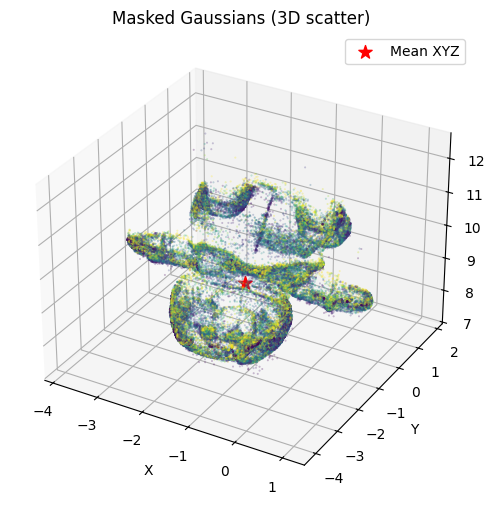

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

xyz = gm.get_xyz.detach().cpu().numpy()      # (N_masked, 3)
op = gm.get_opacity.detach().cpu().numpy()  # (N_masked, 1) 혹은 (N_masked,)

op = op.reshape(-1)
alpha = (op - op.min()) / (op.max() - op.min() + 1e-8)  # 0~1 정규화

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# 마스킹된 가우시안 산점도
ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    c=alpha,
    cmap="viridis",
    s=0.2,          # 점 크기
    alpha=0.3,    # 전체 투명도
)

# mean_xyz 별모양으로 표시
if 'mean_xyz' in locals():
    mxyz = mean_xyz.detach().cpu().numpy()
    ax.scatter(
        mxyz[0],
        mxyz[1],
        mxyz[2],
        color='red',
        s=100,
        marker='*',
        label='Mean XYZ'
    )
    ax.legend()

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Masked Gaussians (3D scatter)")
plt.show()